# Exploratory Data Analysis (EDA) — COVID-19 Radiography Dataset

## Objective
This notebook performs robust exploratory data analysis for the COVID-19 Radiography Dataset used in the chest X-ray classification project.

### What this notebook covers
- dataset structure validation
- safe image path collection
- class distribution analysis
- sample image visualization
- image size analysis
- channel analysis
- pixel intensity analysis
- class-wise intensity comparison
- edge visualization
- approximate duplicate check
- summary insights for modeling

This notebook is written defensively to avoid the path and folder-reading errors that occurred earlier.

## Step 1: Imports

In [1]:
import os
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import cv2

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
random.seed(42)
np.random.seed(42)

## Step 2: Configuration

Update `DATASET_PATH` only if your dataset is stored somewhere else.

Expected structure:
- `COVID/images/...`
- `Lung_Opacity/images/...`
- `Normal/images/...`
- `Viral Pneumonia/images/...`

In [2]:
DATASET_PATH = r"D:\dcgan\data\covid_xray\COVID-19_Radiography_Dataset"

CLASSES = ["COVID", "Lung_Opacity", "Normal", "Viral Pneumonia"]
VALID_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

print("Dataset path:", DATASET_PATH)
print("Classes:", CLASSES)

Dataset path: D:\dcgan\data\covid_xray\COVID-19_Radiography_Dataset
Classes: ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']


## Step 3: Validate dataset folders

In [3]:
for cls in CLASSES:
    folder = os.path.join(DATASET_PATH, cls, "images")
    exists = os.path.isdir(folder)
    count = len(os.listdir(folder)) if exists else 0
    print(f"{cls:18s} | exists: {exists} | entries in images/: {count}")

COVID              | exists: True | entries in images/: 3616
Lung_Opacity       | exists: True | entries in images/: 6012
Normal             | exists: True | entries in images/: 10192
Viral Pneumonia    | exists: True | entries in images/: 1345


## Step 4: Build a clean dataframe of image files only

This cell is the critical fix. It only stores real files with valid image extensions, so folders like `images/` never enter the dataframe.

In [4]:
data = []

for cls in CLASSES:
    class_img_dir = os.path.join(DATASET_PATH, cls, "images")

    if not os.path.isdir(class_img_dir):
        print(f"Skipping missing folder: {class_img_dir}")
        continue

    for name in os.listdir(class_img_dir):
        full_path = os.path.join(class_img_dir, name)

        if os.path.isfile(full_path) and name.lower().endswith(VALID_EXTENSIONS):
            data.append({
                "path": full_path,
                "label": cls,
                "filename": name
            })

df = pd.DataFrame(data)

print("Total image rows:", len(df))
print()
print(df["label"].value_counts())
df.head()

Total image rows: 21165

label
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64


,path,label,filename
0,D:\dcgan\data\covid_xray\COVID-19_Radiography_...,COVID,COVID-1.png
1,D:\dcgan\data\covid_xray\COVID-19_Radiography_...,COVID,COVID-10.png
2,D:\dcgan\data\covid_xray\COVID-19_Radiography_...,COVID,COVID-100.png
3,D:\dcgan\data\covid_xray\COVID-19_Radiography_...,COVID,COVID-1000.png
4,D:\dcgan\data\covid_xray\COVID-19_Radiography_...,COVID,COVID-1001.png


## Step 5: Safety checks

In [5]:
dir_count = df["path"].apply(os.path.isdir).sum()
file_count = df["path"].apply(os.path.isfile).sum()
bad_ext_count = (~df["path"].str.lower().str.endswith(VALID_EXTENSIONS)).sum()

print("Directory paths inside df:", dir_count)
print("Valid file paths inside df:", file_count)
print("Invalid extension rows:", bad_ext_count)

assert dir_count == 0, "df still contains folder paths."
assert bad_ext_count == 0, "df still contains non-image files."
print("\nAll safety checks passed.")

Directory paths inside df: 0
Valid file paths inside df: 21165
Invalid extension rows: 0

All safety checks passed.


## Step 6: Class distribution

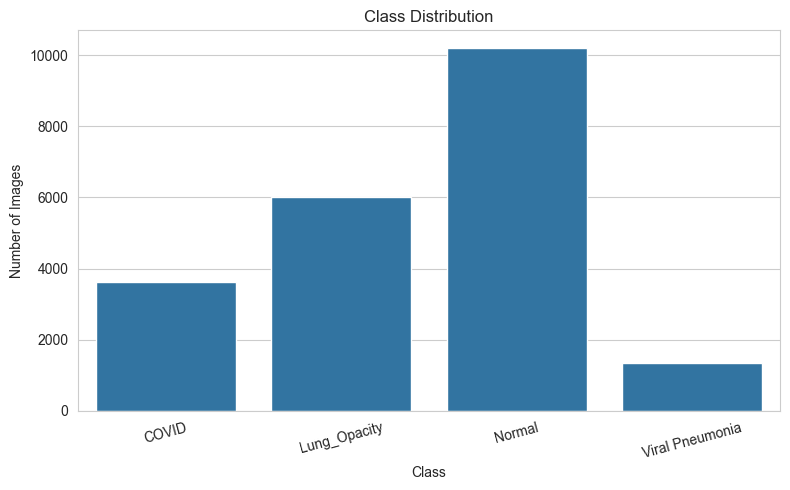

label
COVID               3616
Lung_Opacity        6012
Normal             10192
Viral Pneumonia     1345
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="label", order=CLASSES)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

class_counts = df["label"].value_counts().reindex(CLASSES)
print(class_counts)

## Step 7: Class distribution pie chart

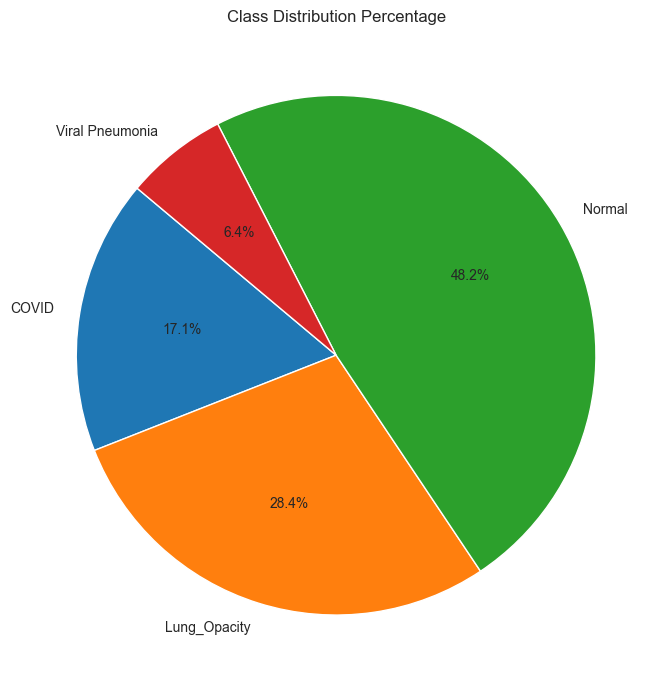

In [7]:
plt.figure(figsize=(7, 7))
plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Class Distribution Percentage")
plt.tight_layout()
plt.show()

## Step 8: Sample images by class

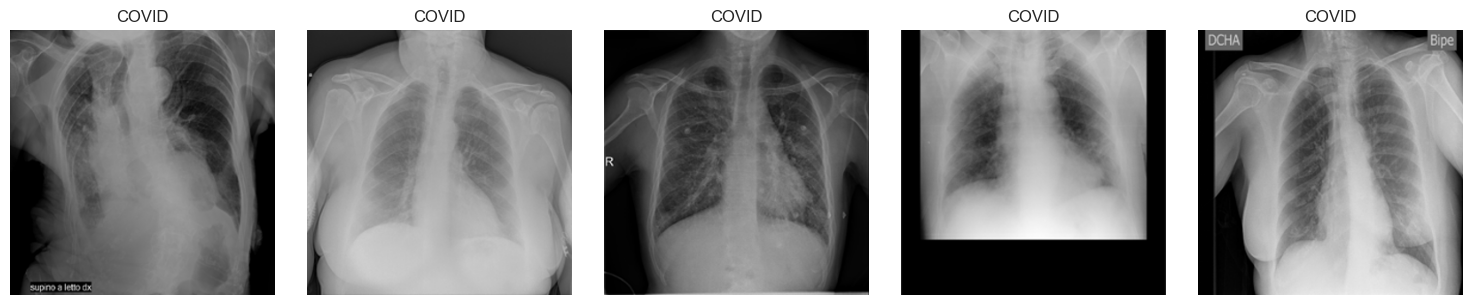

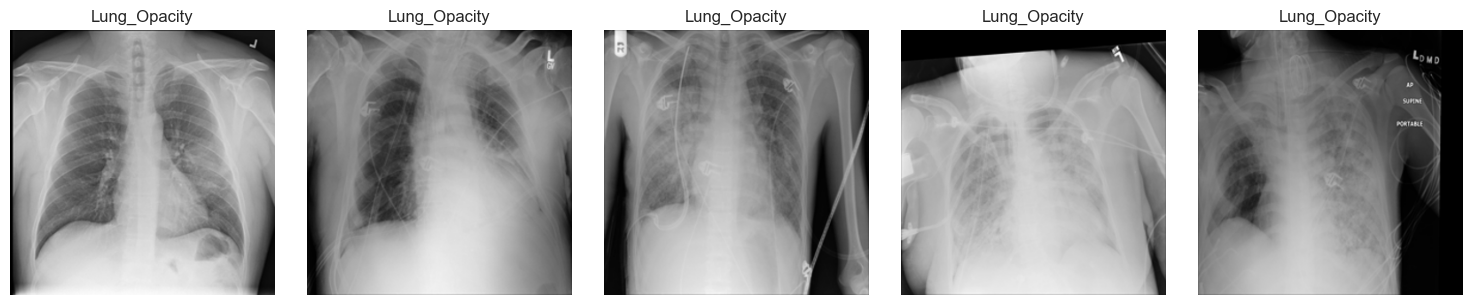

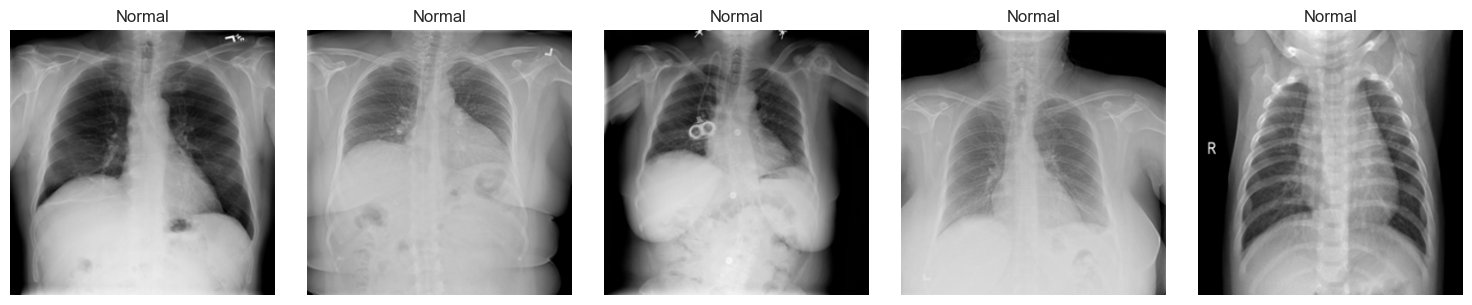

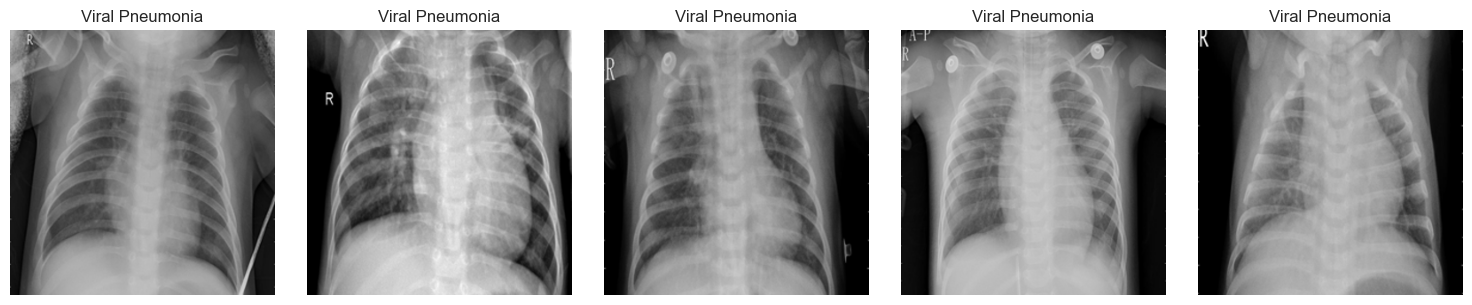

In [8]:
def show_samples(df, class_name, n=5):
    class_df = df[df["label"] == class_name]
    available = len(class_df)

    if available == 0:
        print(f"No images found for class: {class_name}")
        return

    n = min(n, available)
    samples = class_df.sample(n=n, random_state=42)

    plt.figure(figsize=(3*n, 3))
    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(row["path"]).convert("RGB")
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

for cls in CLASSES:
    show_samples(df, cls, n=5)

## Step 9: Image size analysis

We sample up to 2000 images for speed. The loop is wrapped in `try/except` so a single bad image cannot crash the notebook.

100%|██████████| 2000/2000 [00:12<00:00, 162.35it/s]


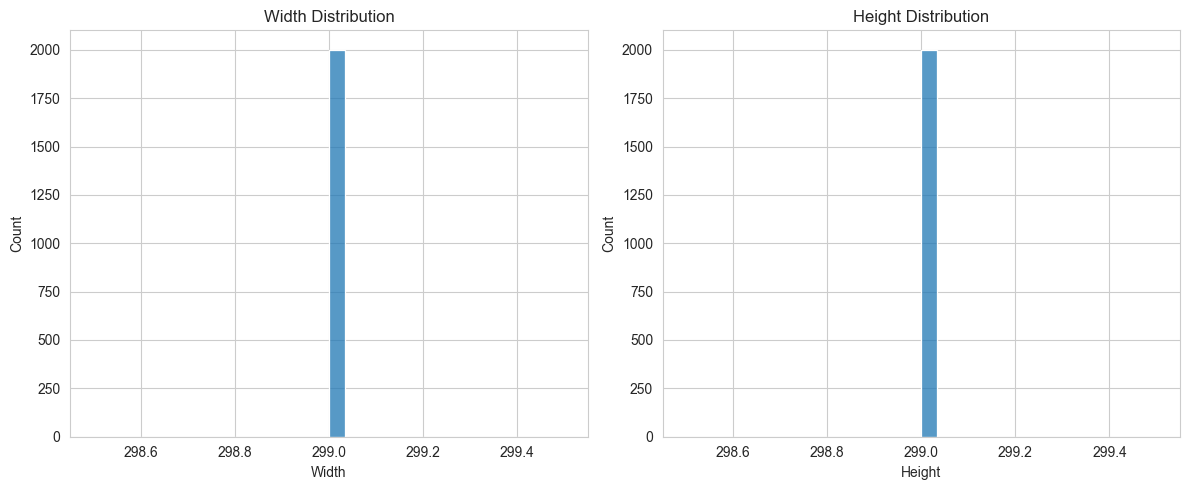

Average size: 299.0 x 299.0
Unique widths (sample): 1
Unique heights (sample): 1


In [9]:
widths, heights = [], []

sample_paths = df["path"].sample(min(2000, len(df)), random_state=42)

for path in tqdm(sample_paths, total=len(sample_paths)):
    try:
        img = Image.open(path)
        w, h = img.size
        widths.append(w)
        heights.append(h)
    except Exception as e:
        print(f"Skipped: {path} | {e}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(widths, bins=30)
plt.title("Width Distribution")
plt.xlabel("Width")

plt.subplot(1, 2, 2)
sns.histplot(heights, bins=30)
plt.title("Height Distribution")
plt.xlabel("Height")

plt.tight_layout()
plt.show()

print("Average size:", round(np.mean(widths), 2), "x", round(np.mean(heights), 2))
print("Unique widths (sample):", len(set(widths)))
print("Unique heights (sample):", len(set(heights)))

## Step 10: Channel analysis

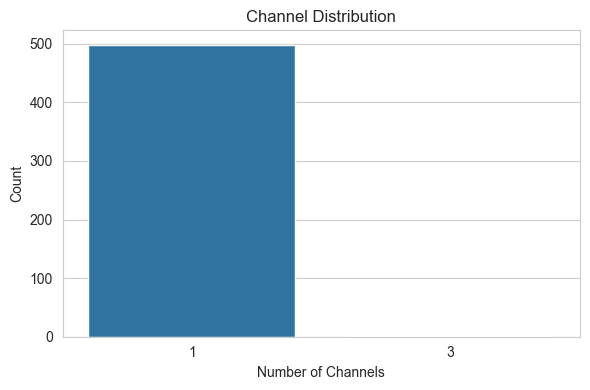

Unique channel counts found: [1, 3]


In [10]:
def num_channels(path):
    try:
        img = Image.open(path)
        return len(img.getbands())
    except Exception:
        return None

channel_counts = [num_channels(p) for p in df["path"].sample(min(500, len(df)), random_state=42)]
channel_counts = [c for c in channel_counts if c is not None]

plt.figure(figsize=(6, 4))
sns.countplot(x=channel_counts)
plt.title("Channel Distribution")
plt.xlabel("Number of Channels")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Unique channel counts found:", sorted(set(channel_counts)))

## Step 11: Pixel intensity distribution

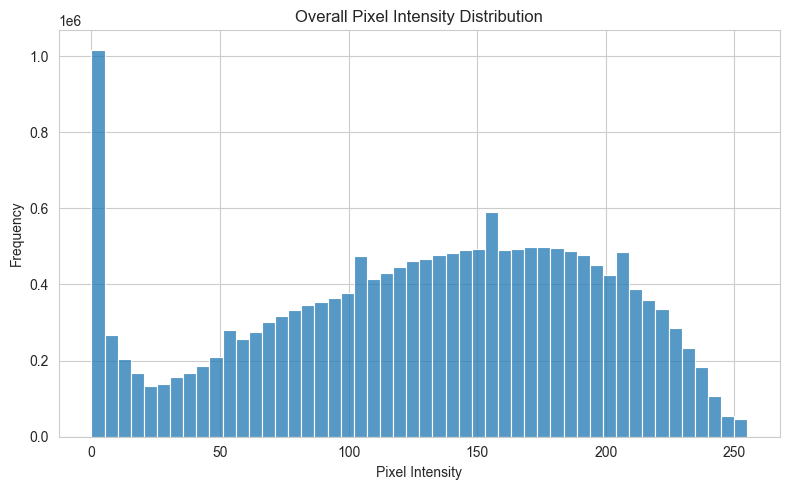

In [11]:
def get_pixel_values(paths, max_images=200):
    pixels = []
    for p in paths[:max_images]:
        try:
            img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                pixels.extend(img.flatten())
        except Exception:
            pass
    return pixels

sample_paths = df["path"].sample(min(200, len(df)), random_state=42).tolist()
pixels = get_pixel_values(sample_paths, max_images=200)

plt.figure(figsize=(8, 5))
sns.histplot(pixels, bins=50)
plt.title("Overall Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Step 12: Class-wise intensity comparison

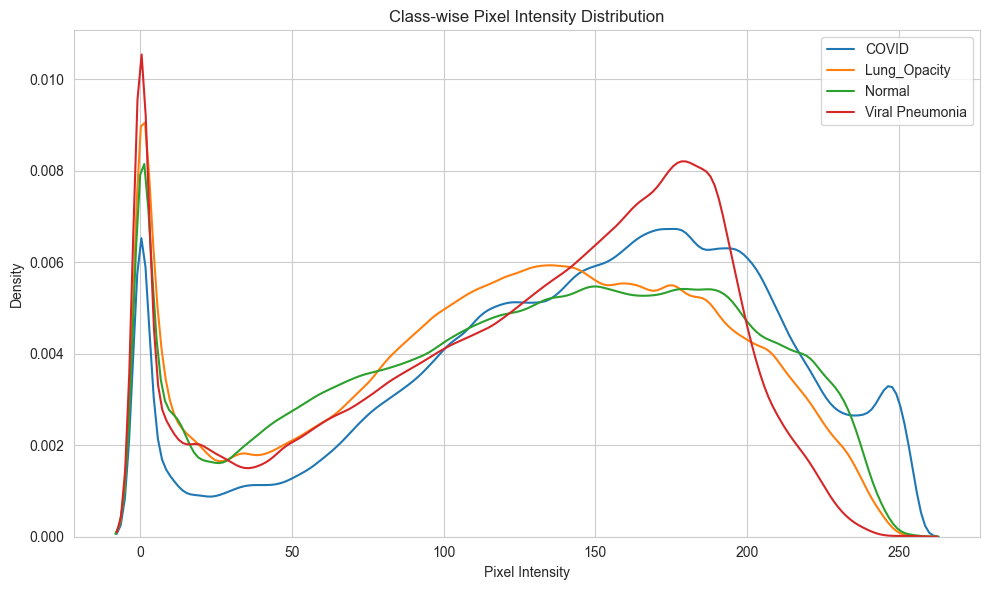

In [12]:
plt.figure(figsize=(10, 6))

for cls in CLASSES:
    cls_df = df[df["label"] == cls]
    cls_paths = cls_df["path"].sample(min(100, len(cls_df)), random_state=42).tolist()
    cls_pixels = get_pixel_values(cls_paths, max_images=100)
    if len(cls_pixels) > 0:
        sns.kdeplot(cls_pixels, label=cls)

plt.title("Class-wise Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## Step 13: Edge visualization

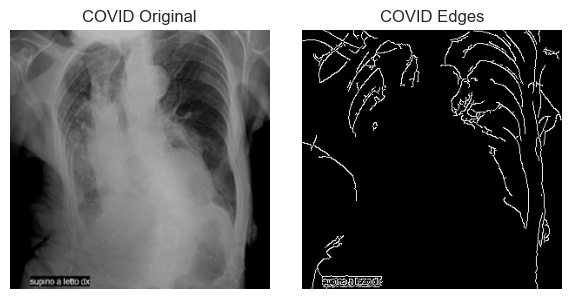

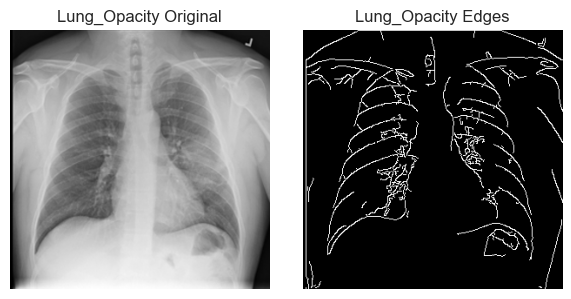

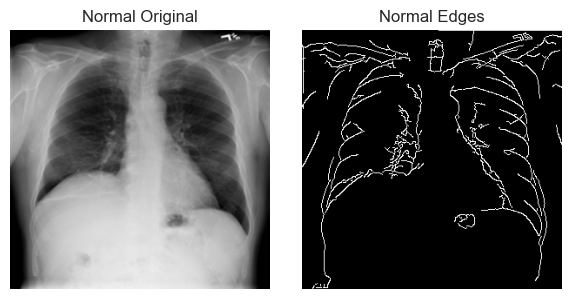

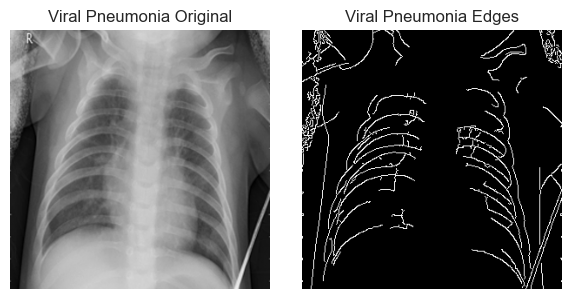

In [13]:
def show_edges(path, title_prefix=""):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    edges = cv2.Canny(img, 50, 150)

    plt.figure(figsize=(6, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"{title_prefix} Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(edges, cmap="gray")
    plt.title(f"{title_prefix} Edges")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

for cls in CLASSES:
    cls_sample = df[df["label"] == cls]["path"].sample(1, random_state=42).iloc[0]
    show_edges(cls_sample, title_prefix=cls)

## Step 14: Approximate duplicate check

In [14]:
hashes = set()
duplicates = 0

sample_for_dupes = df["path"].sample(min(500, len(df)), random_state=42)

for path in sample_for_dupes:
    try:
        img = Image.open(path).resize((64, 64)).convert("L")
        h = hash(img.tobytes())

        if h in hashes:
            duplicates += 1
        else:
            hashes.add(h)
    except Exception:
        pass

print("Approximate duplicate count in sample:", duplicates)

Approximate duplicate count in sample: 0


## Step 15: Optional metadata files check

In [15]:
root_files = os.listdir(DATASET_PATH)
metadata_files = [f for f in root_files if f.lower().endswith((".xlsx", ".csv", ".txt", ".md"))]

print("Non-image root files:")
for f in metadata_files:
    print("-", f)

Non-image root files:
- COVID.metadata.xlsx
- Lung_Opacity.metadata.xlsx
- Normal.metadata.xlsx
- README.md.txt
- Viral Pneumonia.metadata.xlsx
